In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
df = pd.read_excel("First Dataset.xlsx")


In [25]:
df

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,1057,Maryam,M,58.0,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,No,4,4
57,1058,Amir,F,47.0,Tehran,Tehran,2024-09-27,Bronze,5,151.81,759.05,336,Online Wallet,iPhone,No,0,2
58,1059,Ali,F,57.0,Isfahan,Isfahan,2023-09-05,Gold,31,287.05,8898.55,224,Online Wallet,iPhone,Yes,0,5
59,1060,Ali,M,63.0,Tabriz,East Azerbaijan,2021-04-27,Bronze,10,150.18,1501.80,236,Card,Web,Yes,7,3


In [26]:
print("="*50)
print("Shape")
print(df.shape)

print("="*50)
print("Columns")
print(df.columns.tolist())

print("="*50)
print("Info")
print(df.info())

print("="*50)
print("Describe")
print(df.describe(include='all'))

Shape
(61, 17)
Columns
['customer_id', 'first_name', 'gender', 'age', 'city', 'province', 'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days', 'payment_method', 'device', 'discount_used', 'returned_items', 'satisfaction_score']
Info
<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     str    
 2   gender              61 non-null     str    
 3   age                 60 non-null     float64
 4   city                61 non-null     str    
 5   province            61 non-null     str    
 6   signup_date         61 non-null     str    
 7   membership_tier     61 non-null     str    
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 n

In [27]:
print("="*50)
print("Missing Values")
print(df.isnull().sum())

print("="*50)
print("Rows containing Missing Values")
print(df[df.isnull().any(axis=1)])

print("="*50)
print("Duplicate Rows")
print(df.duplicated().sum())

if df.duplicated().sum() > 0:
    print(df[df.duplicated()])

Missing Values
customer_id           0
first_name            0
gender                0
age                   1
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        1
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64
Rows containing Missing Values
    customer_id first_name gender   age     city province signup_date  \
19         1020      Kimia      M   NaN  Isfahan  Isfahan  2024-06-25   
39         1040       Amir      F  65.0   Tehran   Tehran  2021-11-02   

   membership_tier  purchase_count  avg_order_value  total_spending  \
19          Bronze              16           187.17         2994.72   
39          Bronze              34            37.66             NaN   

    last_purchase_days payment_method   device discount_used  returned_items  \
19                 

In [28]:
print("="*50)
for col in df.columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


customer_id
customer_id
1014    2
1001    1
1002    1
1003    1
1004    1
1005    1
1006    1
1007    1
1008    1
1009    1
1010    1
1011    1
1012    1
1013    1
1015    1
1016    1
1017    1
1018    1
1019    1
1020    1
1021    1
1022    1
1023    1
1024    1
1025    1
1026    1
1027    1
1028    1
1029    1
1030    1
1031    1
1032    1
1033    1
1034    1
1035    1
1036    1
1037    1
1038    1
1039    1
1040    1
1041    1
1042    1
1043    1
1044    1
1045    1
1046    1
1047    1
1048    1
1049    1
1050    1
1051    1
1052    1
1053    1
1054    1
1055    1
1056    1
1057    1
1058    1
1059    1
1060    1
Name: count, dtype: int64

first_name
first_name
Reza      8
Sina      8
Neda      8
Kimia     7
Amir      6
Ali       6
Parsa     4
Arash     4
Maryam    4
Mina      3
Zahra     2
Sara      1
Name: count, dtype: int64

gender
gender
F    35
M    26
Name: count, dtype: int64

age
age
58.0     4
23.0     4
60.0     4
47.0     3
37.0     3
25.0     3
19.0     2
53.0     2
31

In [29]:
numeric_cols = df.select_dtypes(include=np.number).columns

outliers = {}

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    temp = df[(df[col] < lower) | (df[col] > upper)]

    if len(temp) > 0:
        outliers[col] = temp

print("="*50)
print("Outliers")

for col,data in outliers.items():
    print(f"\nColumn : {col}")
    print(data[[col]])

Outliers

Column : age
     age
9  145.0

Column : total_spending
    total_spending
8         11615.42
11        11731.50
29        25000.00
43        14354.34
56        13532.74


                    customer_id       age  purchase_count  avg_order_value  \
customer_id            1.000000  0.037262       -0.063921         0.071023   
age                    0.037262  1.000000        0.183692         0.261460   
purchase_count        -0.063921  0.183692        1.000000        -0.272647   
avg_order_value        0.071023  0.261460       -0.272647         1.000000   
total_spending         0.057086  0.351153        0.529820         0.345237   
last_purchase_days     0.214378  0.031753       -0.142649         0.077504   
returned_items        -0.283620  0.075330        0.021270         0.156532   
satisfaction_score    -0.057615 -0.210528        0.099548        -0.168713   

                    total_spending  last_purchase_days  returned_items  \
customer_id               0.057086            0.214378       -0.283620   
age                       0.351153            0.031753        0.075330   
purchase_count            0.529820           -0.142649        0.021270   
a

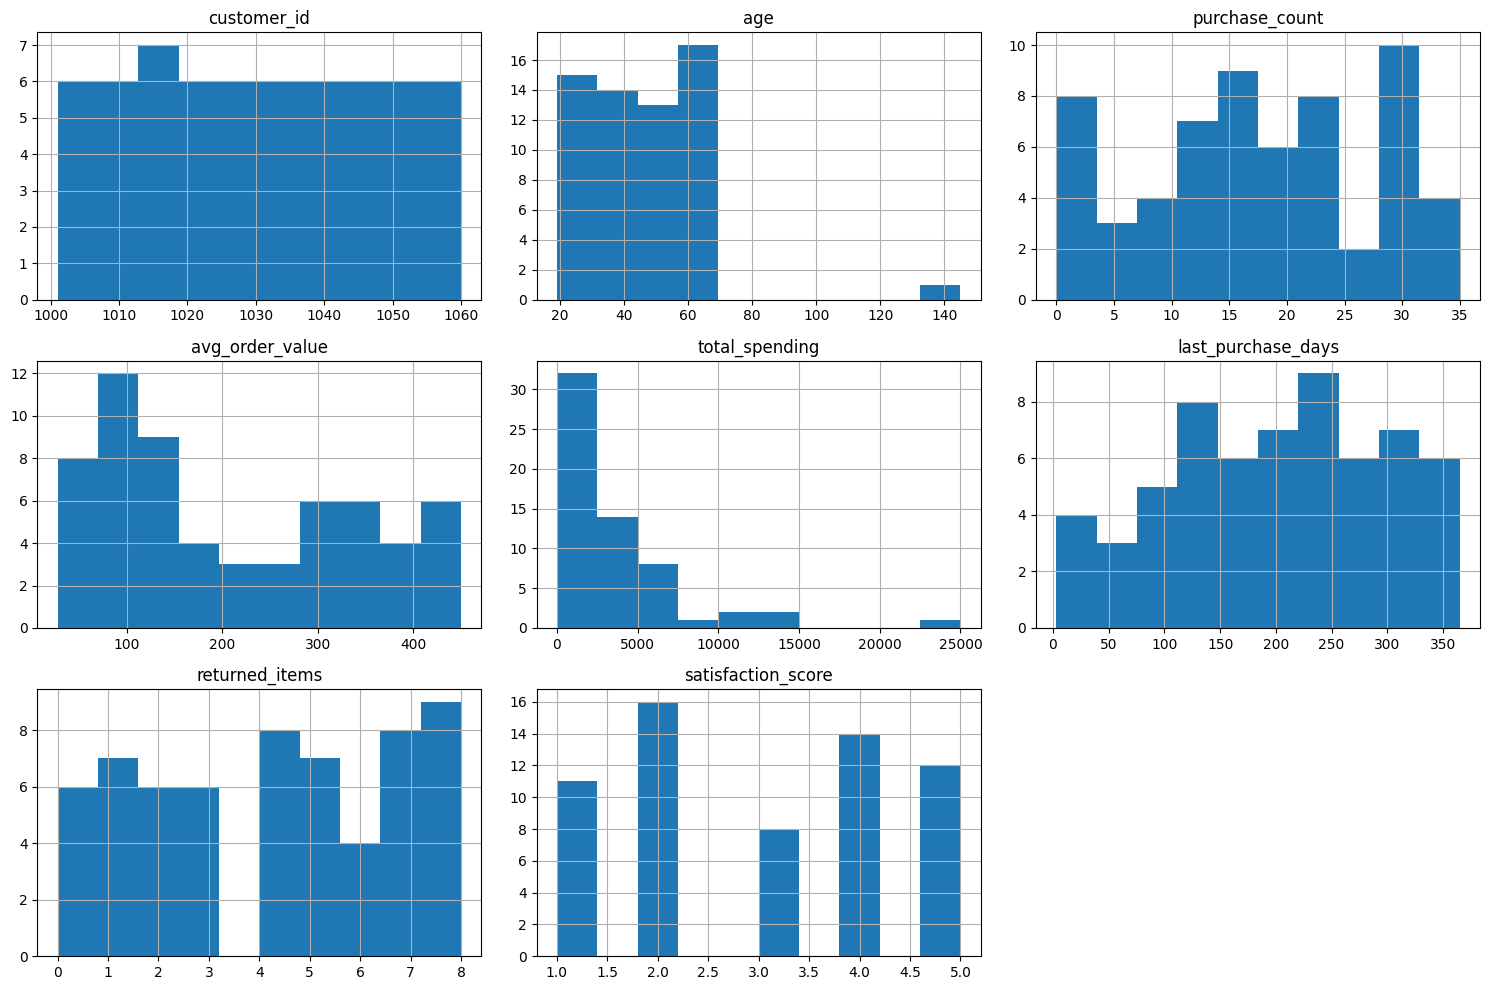

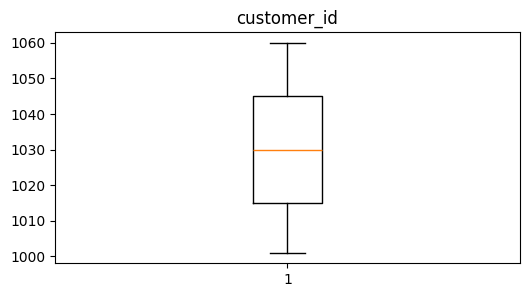

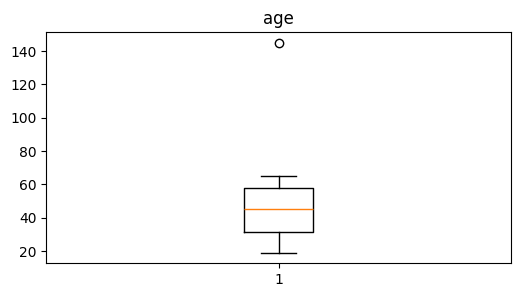

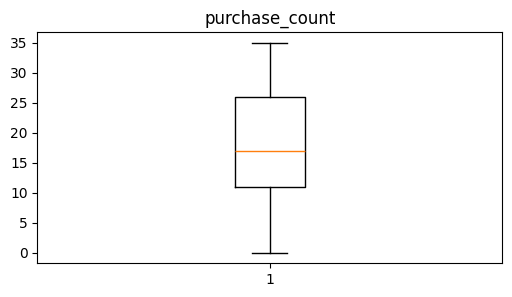

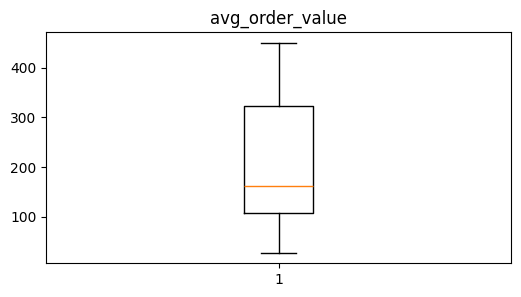

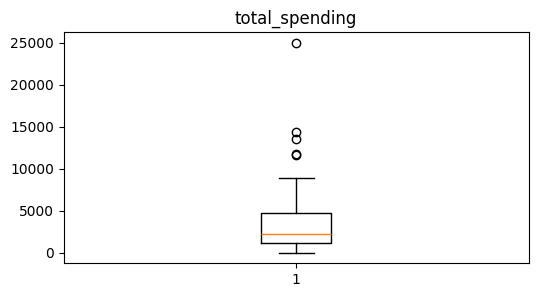

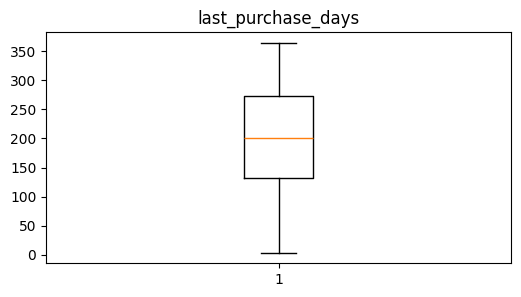

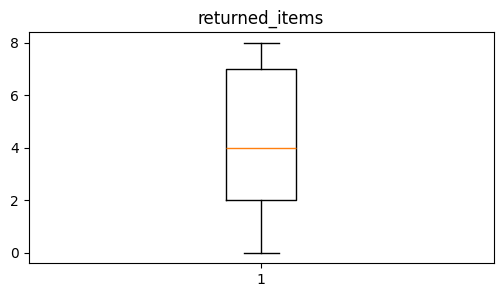

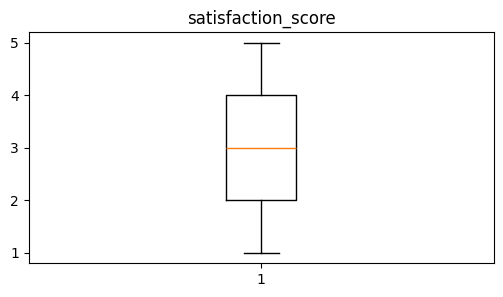

In [30]:

# -----------------------------
# Correlation
# -----------------------------
corr = df.select_dtypes(include=np.number).corr()

print("="*50)
print(corr)

# -----------------------------
# Histograms
# -----------------------------
df[numeric_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

# -----------------------------
# Boxplots
# -----------------------------
for col in numeric_cols:

    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

C:\Users\Hannah\AppData\Local\Temp\ipykernel_24828\3563177234.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


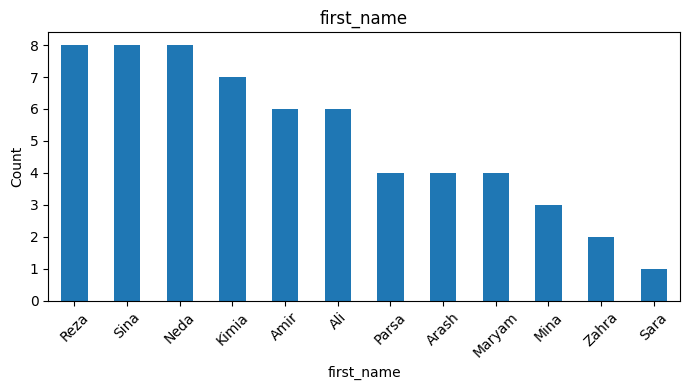

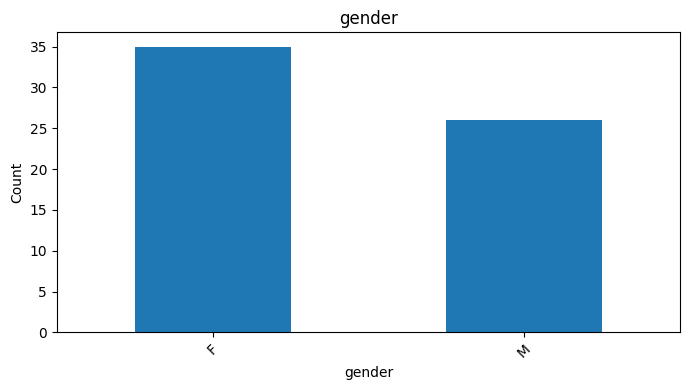

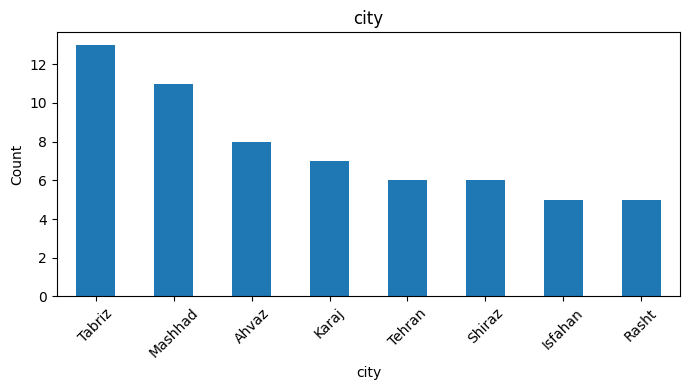

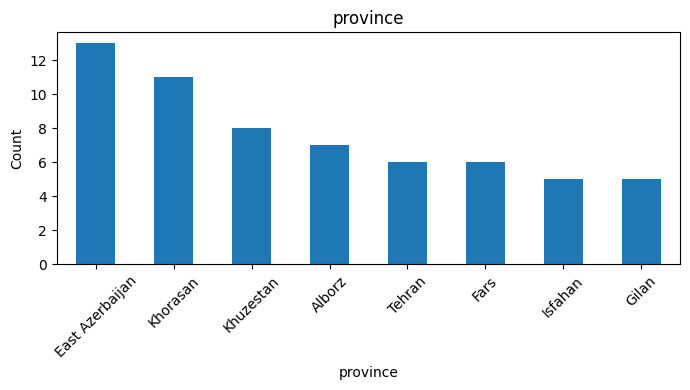

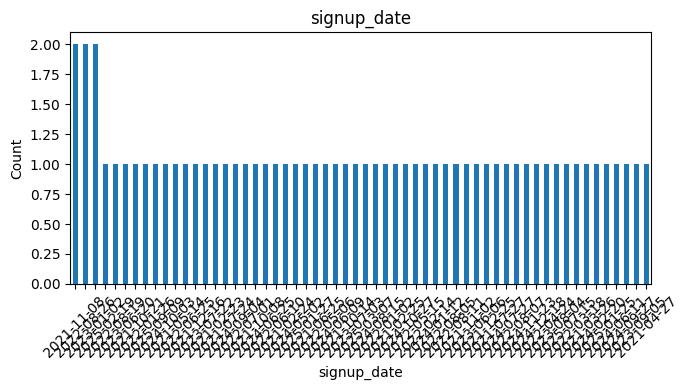

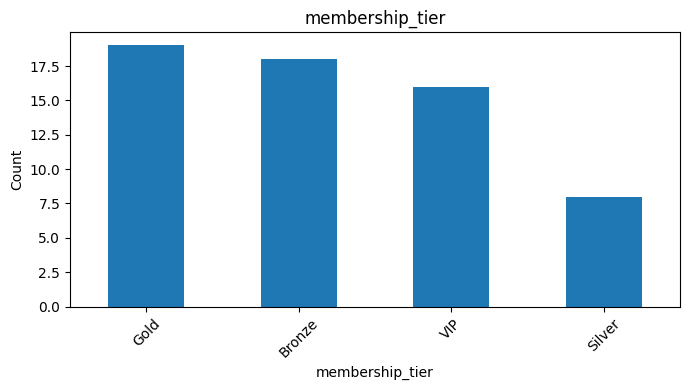

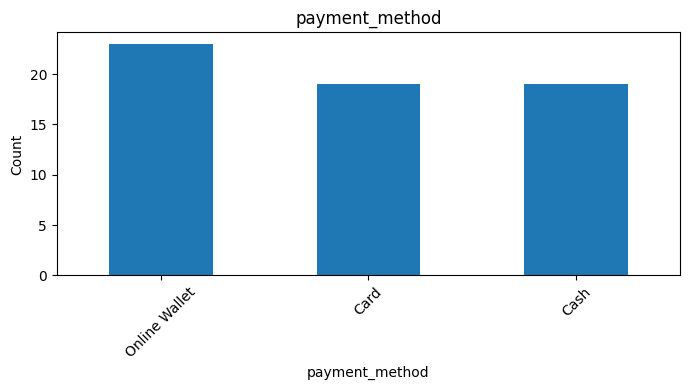

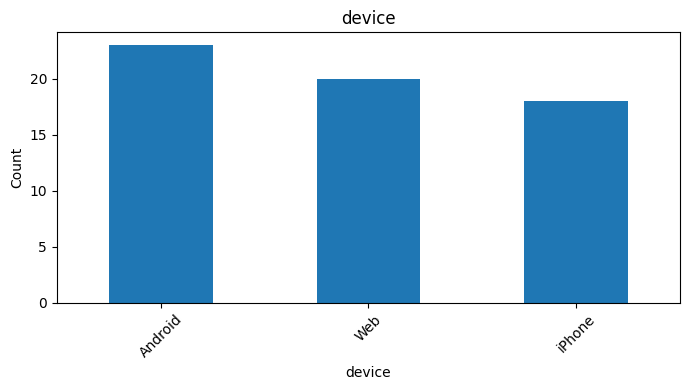

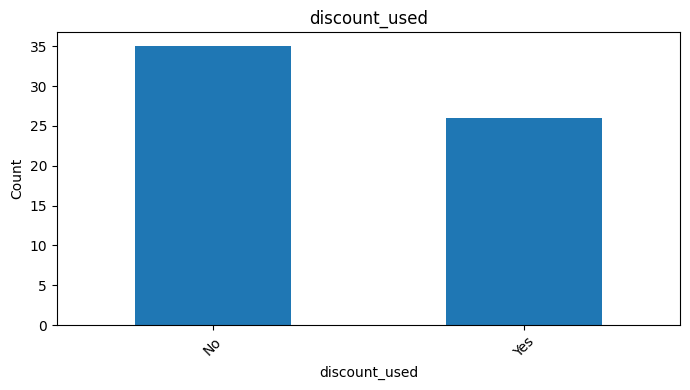

In [31]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:

    plt.figure(figsize=(7,4))
    df[col].value_counts().plot(kind='bar')

    plt.title(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [32]:
print("="*50)

print("Average Spending :", df["total_spending"].mean())
print("Average Order Value :", df["avg_order_value"].mean())
print("Average Purchase Count :", df["purchase_count"].mean())
print("Average Satisfaction :", df["satisfaction_score"].mean())
print("Average Returned Items :", df["returned_items"].mean())

# Top Customers
print("="*50)
print(df.nlargest(10,"total_spending"))

# Lowest Satisfaction
print("="*50)
print(df.nsmallest(10,"satisfaction_score"))

Average Spending : 3749.667333333333
Average Order Value : 211.43573770491804
Average Purchase Count : 17.60655737704918
Average Satisfaction : 3.0
Average Returned Items : 4.19672131147541
    customer_id first_name gender    age     city   province signup_date  \
29         1030       Sina      M   60.0  Mashhad   Khorasan  2025-03-07   
43         1044       Mina      M   64.0   Shiraz       Fars  2024-07-27   
56         1057     Maryam      M   58.0    Ahvaz  Khuzestan  2024-06-11   
11         1012      Arash      F   51.0  Mashhad   Khorasan  2023-07-22   
8          1009      Kimia      M   61.0    Karaj     Alborz  2021-05-14   
58         1059        Ali      F   57.0  Isfahan    Isfahan  2023-09-05   
9          1010      Arash      F  145.0    Karaj     Alborz  2022-06-25   
49         1050       Reza      F   48.0  Mashhad   Khorasan  2023-08-04   
3          1004       Sina      F   58.0  Mashhad   Khorasan  2021-11-08   
54         1055       Mina      M   62.0    Rasht 

In [33]:

gender_map = {
    "Reza": "M",
    "Sina": "M",
    "Parsa": "M",
    "Amir": "M",
    "Arash": "M",
    "Ali": "M",

    "Kimia": "F",
    "Neda": "F",
    "Mina": "F",
    "Maryam": "F",
    "Zahra": "F",
    "Sara": "F"
}

df["gender"] = df["first_name"].map(gender_map)

In [34]:
gender_map = {
    "Reza":"M","Sina":"M","Parsa":"M","Amir":"M","Arash":"M","Ali":"M",
    "Kimia":"F","Neda":"F","Mina":"F","Maryam":"F","Zahra":"F","Sara":"F"
}

mask = df["gender"] != df["first_name"].map(gender_map)

print(df.loc[mask, ["customer_id","first_name","gender"]])

df.loc[mask, "gender"] = df.loc[mask, "first_name"].map(gender_map)

Empty DataFrame
Columns: [customer_id, first_name, gender]
Index: []


In [35]:
df = pd.read_excel("First Dataset.xlsx")
df = df.drop_duplicates(keep="first")

In [36]:
df.loc[df["customer_id"] == 1010, "age"] = np.nan
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)
print("Median Age:", median_age)

Median Age: 45.0


In [37]:
df.loc[df["customer_id"] == 1010, "age"] = np.nan

df["age"] = df.groupby("gender")["age"].transform(
    lambda x: x.fillna(x.median())
)

In [38]:
df.loc[df["customer_id"] == 1040, "total_spending"] = (
    df.loc[df["customer_id"] == 1040, "purchase_count"] *
    df.loc[df["customer_id"] == 1040, "avg_order_value"]
)

In [39]:
df.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1030.500000,43.650000,17.383333,213.156500,3715.109833,198.600000,4.183333,2.983333
std,17.464249,13.947632,10.149880,130.509923,4273.901437,97.843043,2.683861,1.431979
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1015.750000,31.750000,10.750000,108.137500,1167.035000,134.250000,2.000000,2.000000
50%,1030.500000,45.000000,17.000000,165.435000,2128.690000,203.000000,4.000000,3.000000
75%,1045.250000,58.000000,24.500000,324.107500,4692.150000,273.750000,7.000000,4.000000
max,1060.000000,65.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.000000


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    "gender",
    "membership_tier",
    "payment_method",
    "device",
    "city"
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [41]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df["signup_date"] = pd.to_datetime(df["signup_date"])

df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month

df = df.drop(columns=["signup_date"])

membership = {
    "Bronze":0,
    "Silver":1,
    "Gold":2,
    "Platinum":3
}

df["membership_tier"] = df["membership_tier"].map(membership)

df["discount_used"] = df["discount_used"].map({
    "Yes":1,
    "No":0
})

le = LabelEncoder()

cat_cols = [
    "first_name",
    "gender",
    "city",
    "province",
    "payment_method",
    "device"
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()

num_cols = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score",
    "signup_year",
    "signup_month"
]

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head())

   customer_id  first_name  gender       age  city  province  membership_tier  \
0         1001           8       0 -1.782239     2         0              NaN   
1         1002          10       1  0.676022     7         7              NaN   
2         1003           7       0 -0.914618     5         2              NaN   
3         1004          10       0  1.037531     3         5              NaN   
4         1005           3       1 -1.131523     1         4              NaN   

   purchase_count  avg_order_value  total_spending  last_purchase_days  \
0       -0.038086        -0.707990       -0.389110           -1.882004   
1       -0.534860         0.875564        0.047788           -2.015991   
2        0.359333        -1.187600       -0.581966           -1.820163   
3        0.558043         0.409476        0.567783           -1.634643   
4        0.558043        -0.337021        0.043488            0.766819   

   payment_method  device  discount_used  returned_items  satisfacti

In [ ]:
from scipy.stats import (
    spearmanr,
    mannwhitneyu,
    kruskal
)

# ------------------------
# Load Data
# ------------------------

df = pd.read_excel("First Dataset_Clean.xlsx")

target = "satisfaction_score"

# حذف شناسه
if "customer_id" in df.columns:
    df = df.drop(columns=["customer_id"])

results = []

# ------------------------
# Loop over Features
# ------------------------

for col in df.columns:

    if col == target:
        continue

    data = df[[col, target]].dropna()

    # ---------- Numeric ----------
    if pd.api.types.is_numeric_dtype(data[col]):

        coef, p = spearmanr(data[col], data[target])

        results.append({
            "Feature": col,
            "Test": "Spearman Correlation",
            "Statistic": round(coef,4),
            "P-value": round(p,5),
            "Significant": "YES" if p < 0.05 else "NO"
        })

    # ---------- Categorical ----------
    else:

        n_unique = data[col].nunique()

        # Binary
        if n_unique == 2:

            groups = [
                g[target].values
                for _, g in data.groupby(col)
            ]

            stat, p = mannwhitneyu(
                groups[0],
                groups[1],
                alternative='two-sided'
            )

            results.append({
                "Feature": col,
                "Test": "Mann-Whitney U",
                "Statistic": round(stat,4),
                "P-value": round(p,5),
                "Significant": "YES" if p < 0.05 else "NO"
            })

        # Multi-category
        else:

            groups = [
                g[target].values
                for _, g in data.groupby(col)
            ]

            stat, p = kruskal(*groups)

            results.append({
                "Feature": col,
                "Test": "Kruskal-Wallis",
                "Statistic": round(stat,4),
                "P-value": round(p,5),
                "Significant": "YES" if p < 0.05 else "NO"
            })

# ------------------------
# Output
# ------------------------

results = pd.DataFrame(results)

results = results.sort_values("P-value")

print(results)

# ذخیره
results.to_excel("Significance_Test_Result.xlsx", index=False)

In [42]:

from scipy.stats import (
    spearmanr,
    mannwhitneyu,
    kruskal
)


target = "satisfaction_score"

if "customer_id" in df.columns:
    df = df.drop(columns=["customer_id"])

results = []

for col in df.columns:

    if col == target:
        continue

    data = df[[col, target]].dropna()


    if pd.api.types.is_numeric_dtype(data[col]):

        coef, p = spearmanr(data[col], data[target])

        results.append({
            "Feature": col,
            "Test": "Spearman Correlation",
            "Statistic": round(coef,4),
            "P-value": round(p,5),
            "Significant": "YES" if p < 0.05 else "NO"
        })

    else:

        n_unique = data[col].nunique()

        if n_unique == 2:

            groups = [
                g[target].values
                for _, g in data.groupby(col)
            ]

            stat, p = mannwhitneyu(
                groups[0],
                groups[1],
                alternative='two-sided'
            )

            results.append({
                "Feature": col,
                "Test": "Mann-Whitney U",
                "Statistic": round(stat,4),
                "P-value": round(p,5),
                "Significant": "YES" if p < 0.05 else "NO"
            })

        else:

            groups = [
                g[target].values
                for _, g in data.groupby(col)
            ]

            stat, p = kruskal(*groups)

            results.append({
                "Feature": col,
                "Test": "Kruskal-Wallis",
                "Statistic": round(stat,4),
                "P-value": round(p,5),
                "Significant": "YES" if p < 0.05 else "NO"
            })

results = pd.DataFrame(results)

results = results.sort_values("P-value")

print(results)

               Feature                  Test  Statistic  P-value Significant
10      payment_method  Spearman Correlation    -0.2975  0.02098         YES
13      returned_items  Spearman Correlation    -0.2831  0.02837         YES
9   last_purchase_days  Spearman Correlation    -0.2831  0.02841         YES
3                 city  Spearman Correlation    -0.2237  0.08577          NO
12       discount_used  Spearman Correlation     0.1789  0.17142          NO
15        signup_month  Spearman Correlation     0.1545  0.23849          NO
7      avg_order_value  Spearman Correlation    -0.1498  0.25315          NO
2                  age  Spearman Correlation    -0.1058  0.42101          NO
4             province  Spearman Correlation     0.0726  0.58145          NO
6       purchase_count  Spearman Correlation     0.0624  0.63581          NO
11              device  Spearman Correlation    -0.0488  0.71102          NO
8       total_spending  Spearman Correlation    -0.0245  0.85285          NO

In [43]:
df.to_excel("First Dataset_Clean.xlsx", index=False)